# Phase 2 — Time Series EDA

Exploratory analysis of **Phase 1** output (`usa_fortnight_features.csv`).

**Input:** fortnight field features (Texas-only or multi-state)  
**Focus:** time-series vegetation indices, distributions, correlations, and data quality.

Run in Google Colab after Phase 1 saves `usa_fortnight_features.csv`, or locally with the CSV in the same folder.


In [ ]:

# --- CONFIG ---
INPUT_CSV = 'usa_fortnight_features.csv'

# Auto-search these paths in Colab if INPUT_CSV is not in the working directory
CSV_SEARCH_PATHS = [
    'usa_fortnight_features.csv',
    '/content/usa_fortnight_features.csv',
    '/content/drive/MyDrive/usa_fortnight_features.csv',
]

# Field to highlight in single-field time-series plots (change after loading)
SAMPLE_FIELD_ID = 1

# Main vegetation indices for plots (matches Phase 1 output)
VEG_FEATURES = ['NDVI', 'EVI', 'GNDVI', 'SAVI']
EXTRA_FEATURES = ['MOISTURE', 'LAI']

# Correlation heatmap uses a focused feature set (keeps plot readable)
CORR_FEATURES = [
    'NDVI', 'EVI', 'GNDVI', 'SAVI', 'MSAVI', 'VCI',
    'MOISTURE', 'LAI', 'NDMI_8', 'NDWI_8', 'Elevation'
]

# Backfill if Phase 1 merge skipped state_annual_yield
STATE_ANNUAL_YIELDS = {
    'Florida':   {2019: 43.0, 2021: 42.6, 2022: 44.6},
    'Louisiana': {2019: 28.1, 2021: 29.3, 2022: 32.3},
    'Texas':     {2019: 33.8, 2021: 30.9, 2022: 22.6},
}


In [2]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='husl')
%matplotlib inline

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def resolve_input_csv():
    if os.path.exists(INPUT_CSV):
        return INPUT_CSV
    for path in CSV_SEARCH_PATHS:
        if os.path.exists(path):
            return path
    if IN_COLAB:
        drive_matches = sorted(glob.glob('/content/drive/MyDrive/**/usa_fortnight_features.csv', recursive=True))
        if drive_matches:
            return drive_matches[0]
    if IN_COLAB:
        print(f'{INPUT_CSV} not found — upload Phase 1 output:')
        uploaded = files.upload()
        return next(iter(uploaded))
    raise FileNotFoundError(f'Place {INPUT_CSV} next to this notebook or set INPUT_CSV')


def clean_phase1_export(raw_df):
    """Normalize Phase 1 / Earth Engine export columns for EDA."""
    df = raw_df.copy()

    drop_cols = ['.geo', 'system:index']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    if 'Area' not in df.columns and 'area' in df.columns:
        df['Area'] = df['area']

    if 'field_id' in df.columns:
        df['field_id'] = pd.to_numeric(df['field_id'], errors='coerce').astype('Int64')

    if 'year' in df.columns:
        df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    if 'state' not in df.columns or df['state'].isna().all():
        df['state'] = 'Texas'

    if 'state_annual_yield' not in df.columns:
        lookup = {
            (state, year): val
            for state, years in STATE_ANNUAL_YIELDS.items()
            for year, val in years.items()
        }
        df['state_annual_yield'] = df.apply(
            lambda r: lookup.get((r.get('state'), int(r['year'])) if pd.notna(r.get('year')) else None),
            axis=1,
        )

    if 'fortnight_end' not in df.columns and 'fortnight_start' in df.columns:
        df['fortnight_end'] = pd.to_datetime(df['fortnight_start']) + pd.Timedelta(days=14)

    before = len(df)
    df = df.drop_duplicates(subset=['field_id', 'fortnight_start'], keep='last')
    if before != len(df):
        print(f'Removed {before - len(df)} duplicate field/fortnight rows')

    return df


csv_path = resolve_input_csv()
print('Loading:', csv_path)
raw_df = pd.read_csv(csv_path)
df = clean_phase1_export(raw_df)
print('Shape:', df.shape)
print('Columns:', len(df.columns))
df.head()


usa_fortnight_features.csv not found — upload Phase 1 output:


Saving usa_fortnight_features.csv to usa_fortnight_features.csv
Loading: usa_fortnight_features.csv
Shape: (50832, 69)
Columns: 69


,ASI,Area,B1,B11,B12,B2,B3,B4,B5,B6,...,area,field_id,fortnight_end,fortnight_start,label,mean,s2_scene_count,state,year,state_annual_yield
0,0.274030,26.514191,452.560882,2334.970376,2113.836332,643.106629,815.964104,957.046262,1168.296240,1452.805501,...,26.514191,1,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
1,0.200750,0.445614,390.785714,2649.330357,2465.326786,581.816071,702.201786,956.333929,1118.978571,1191.910714,...,0.445614,2,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
2,0.203519,0.668428,614.389208,3169.438576,3034.840413,859.788749,1075.184845,1343.337543,1565.591274,1738.748565,...,0.668428,3,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
3,0.200886,0.668428,658.382527,3236.122786,3105.825266,884.552538,1098.811098,1364.779221,1587.906730,1754.465171,...,0.668428,4,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
4,0.171391,3.564942,346.524071,2221.554188,2150.813805,551.124643,663.971202,891.705210,1022.420092,1064.955595,...,3.564942,5,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8


In [3]:
META_COLS = ['field_id', 'state', 'year', 'fortnight_start', 'fortnight_end', 'state_annual_yield', 'Area', 's2_scene_count']

missing_meta = [c for c in META_COLS if c not in df.columns]
if missing_meta:
    print('Warning: missing meta columns:', missing_meta)

# Parse fortnight dates and sort for time-series plots
df['fortnight_start'] = pd.to_datetime(df['fortnight_start'])
df['fortnight_end'] = pd.to_datetime(df['fortnight_end'])
df = df.sort_values(['field_id', 'fortnight_start']).reset_index(drop=True)

rows_per_field = df.groupby('field_id').size()
print('Date range:', df['fortnight_start'].min().date(), '→', df['fortnight_start'].max().date())
print('States:', sorted(df['state'].dropna().unique()))
print('Years:', sorted(int(y) for y in df['year'].dropna().unique()))
print('Unique fields:', df['field_id'].nunique())
print('Fortnight periods:', df['fortnight_start'].nunique())
print('Rows per field — median:', rows_per_field.median(), '| min:', rows_per_field.min(), '| max:', rows_per_field.max())


Date range: 2019-01-01 → 2022-12-15
States: ['Texas']
Years: [2019, 2021, 2022]
Unique fields: 706
Fortnight periods: 72
Rows per field — median: 72.0 | min: 72 | max: 72



## 1. Dataset overview & missing data


In [4]:
overview = pd.DataFrame({
    'rows': [len(df)],
    'fields': [df['field_id'].nunique()],
    'states': [df['state'].nunique()],
    'years': [df['year'].nunique()],
    'fortnights': [df['fortnight_start'].nunique()],
    'duplicate_field_date': [df.duplicated(['field_id', 'fortnight_start']).sum()],
})
overview.T

,0
rows,50832
fields,706
states,1
years,3
fortnights,72
duplicate_field_date,0


In [5]:
# Missing values on key columns
check_cols = META_COLS + VEG_FEATURES + EXTRA_FEATURES
missing = df[check_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')


,missing,pct
NDVI,6406,12.60
SAVI,6406,12.60
GNDVI,6406,12.60
EVI,6406,12.60
s2_scene_count,6406,12.60
LAI,1203,2.37


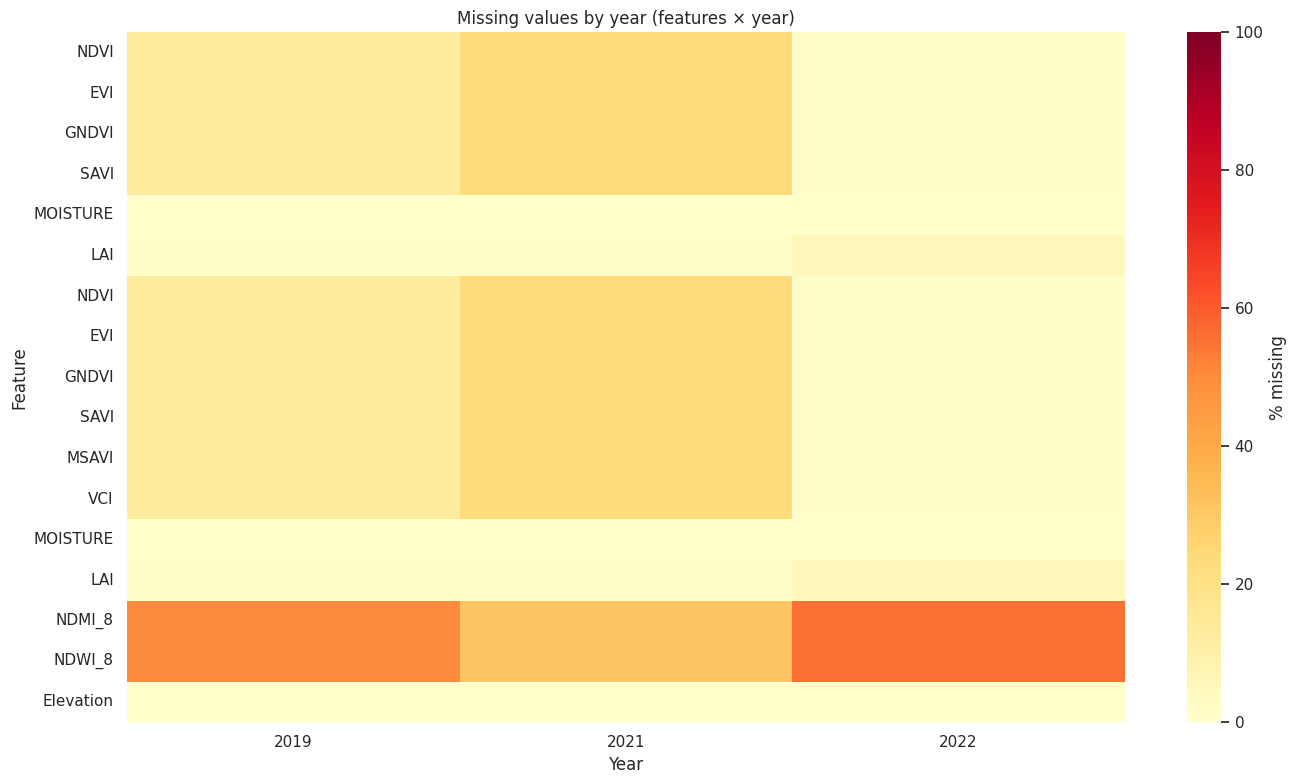

In [6]:
# Missing-data heatmap: % missing per feature × year (focused feature set)
heatmap_features = [c for c in (VEG_FEATURES + EXTRA_FEATURES + CORR_FEATURES) if c in df.columns]
miss_by_year = df.groupby('year')[heatmap_features].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(14, 8))
sns.heatmap(miss_by_year.T, cmap='YlOrRd', vmin=0, vmax=100, cbar_kws={'label': '% missing'})
plt.title('Missing values by year (features × year)')
plt.xlabel('Year')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

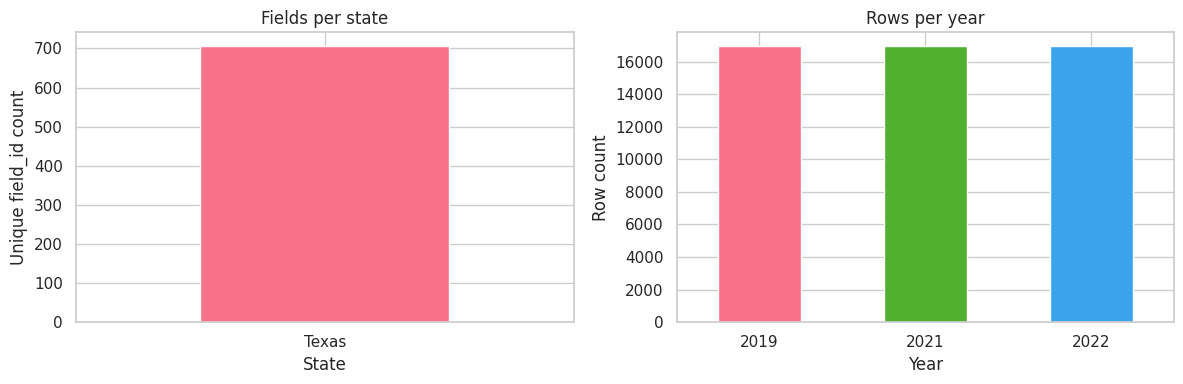

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

state_counts = df.groupby('state')['field_id'].nunique()
state_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', len(state_counts)))
axes[0].set_title('Fields per state')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Unique field_id count')
axes[0].tick_params(axis='x', rotation=0)

year_counts = df.groupby('year').size()
year_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('husl', len(year_counts)))
axes[1].set_title('Rows per year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Row count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 2. Time series — state-level vegetation indices

State mean ± std across all fields per fortnight (main growing-season signal).


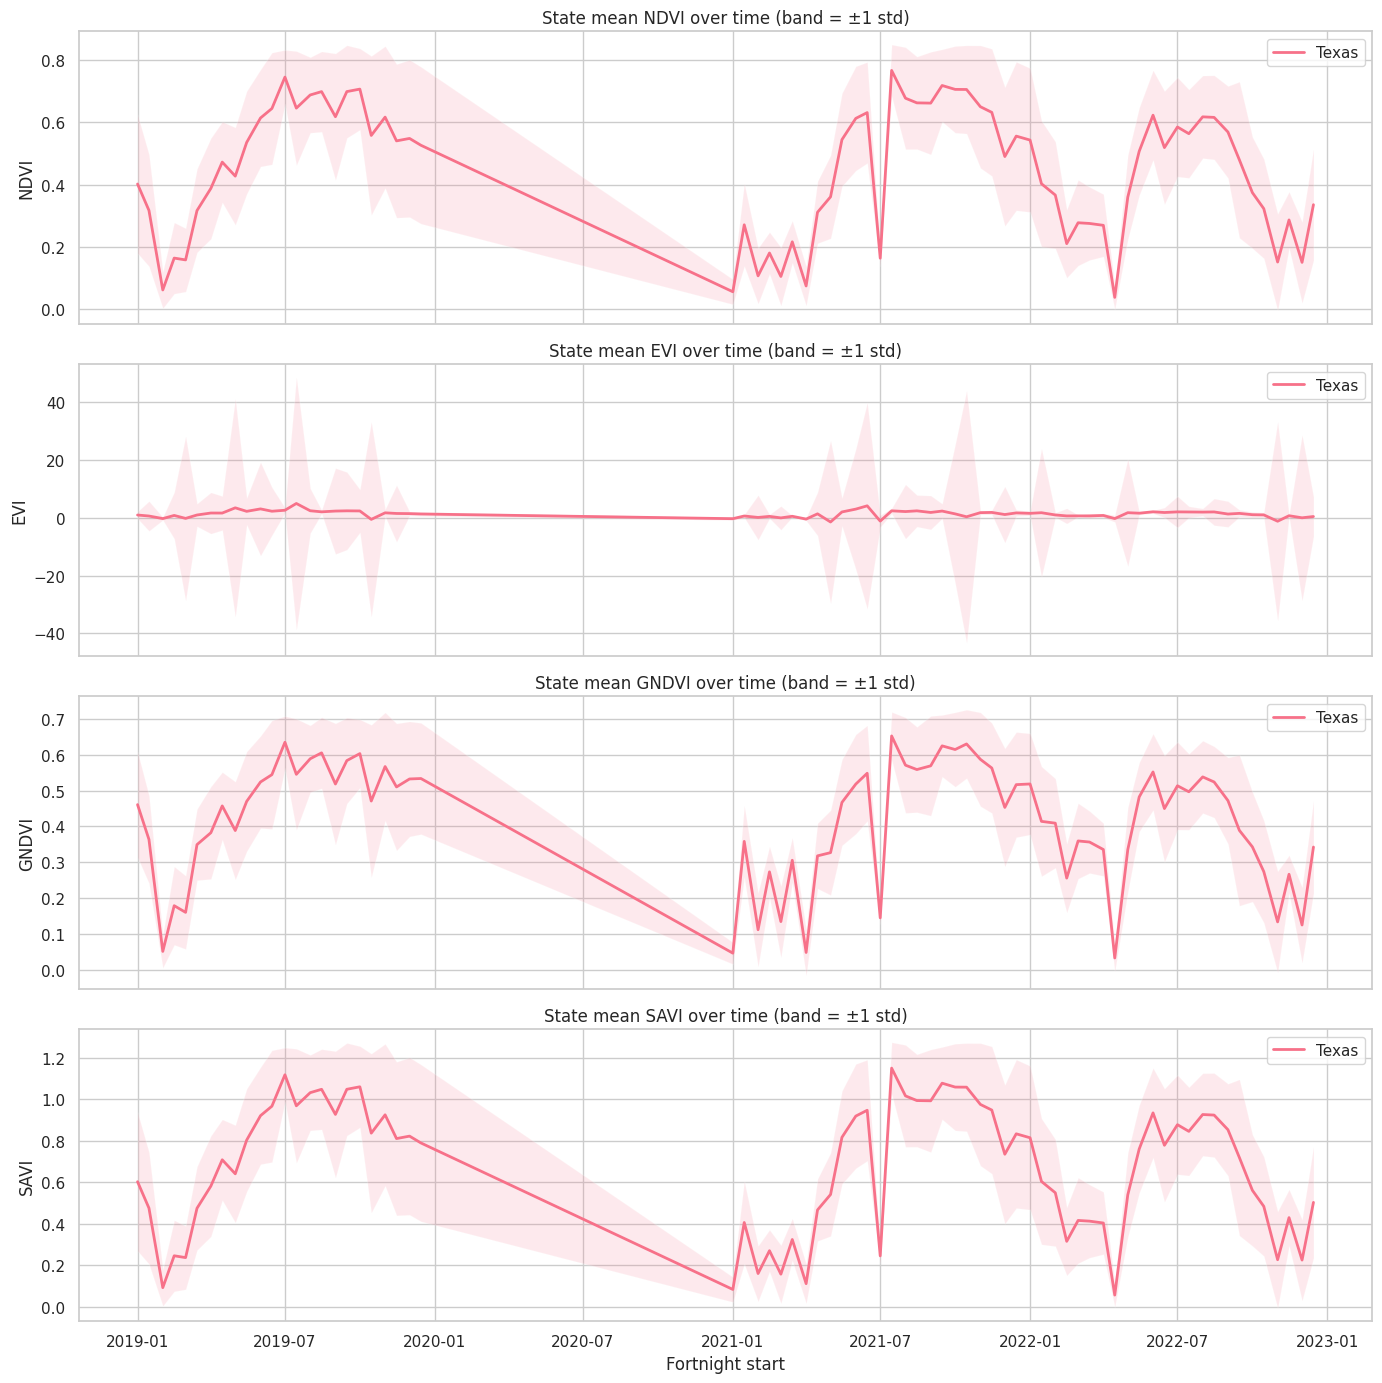

In [8]:
state_ts = (
    df.groupby(['state', 'year', 'fortnight_start'])[VEG_FEATURES]
    .agg(['mean', 'std'])
    .reset_index()
)

fig, axes = plt.subplots(len(VEG_FEATURES), 1, figsize=(14, 3.5 * len(VEG_FEATURES)), sharex=True)
if len(VEG_FEATURES) == 1:
    axes = [axes]

for ax, feat in zip(axes, VEG_FEATURES):
    for state in sorted(df['state'].dropna().unique()):
        sub = state_ts[state_ts['state'] == state]
        ax.plot(sub['fortnight_start'], sub[(feat, 'mean')], label=state, linewidth=2)
        ax.fill_between(
            sub['fortnight_start'],
            sub[(feat, 'mean')] - sub[(feat, 'std')],
            sub[(feat, 'mean')] + sub[(feat, 'std')],
            alpha=0.15,
        )
    ax.set_ylabel(feat)
    ax.legend(loc='upper right')
    ax.set_title(f'State mean {feat} over time (band = ±1 std)')

axes[-1].set_xlabel('Fortnight start')
plt.tight_layout()
plt.show()

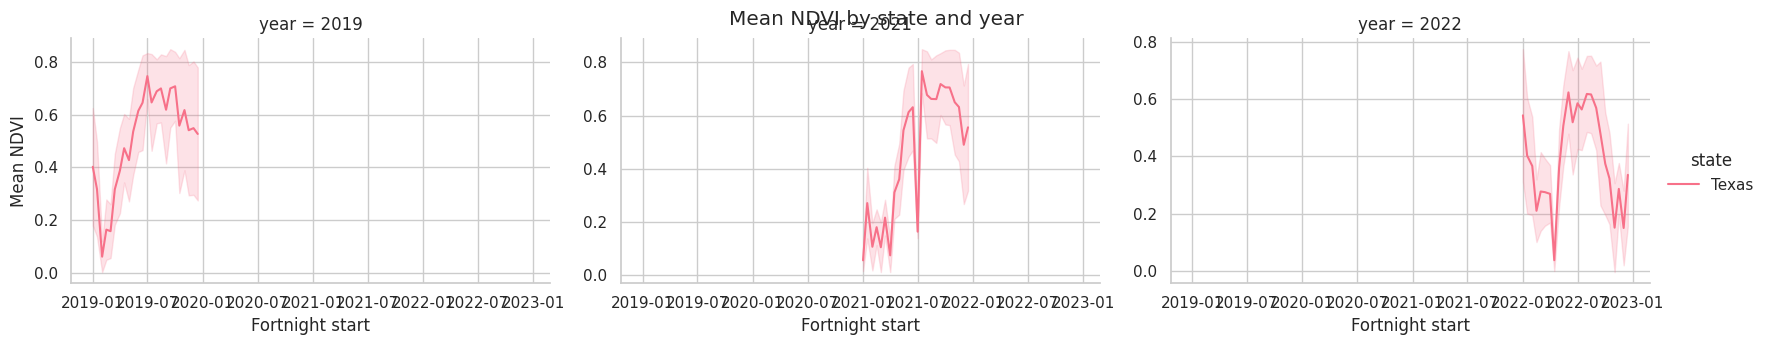

In [9]:
# Facet by year — NDVI per state (Sugarcane-style bar/line comparison, improved for time axis)
g = sns.relplot(
    data=df,
    x='fortnight_start', y='NDVI', hue='state', col='year', col_wrap=3,
    kind='line', estimator='mean', errorbar='sd', height=3.5, aspect=1.6,
    facet_kws={'sharey': False},
)
g.set_axis_labels('Fortnight start', 'Mean NDVI')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Mean NDVI by state and year')
plt.show()

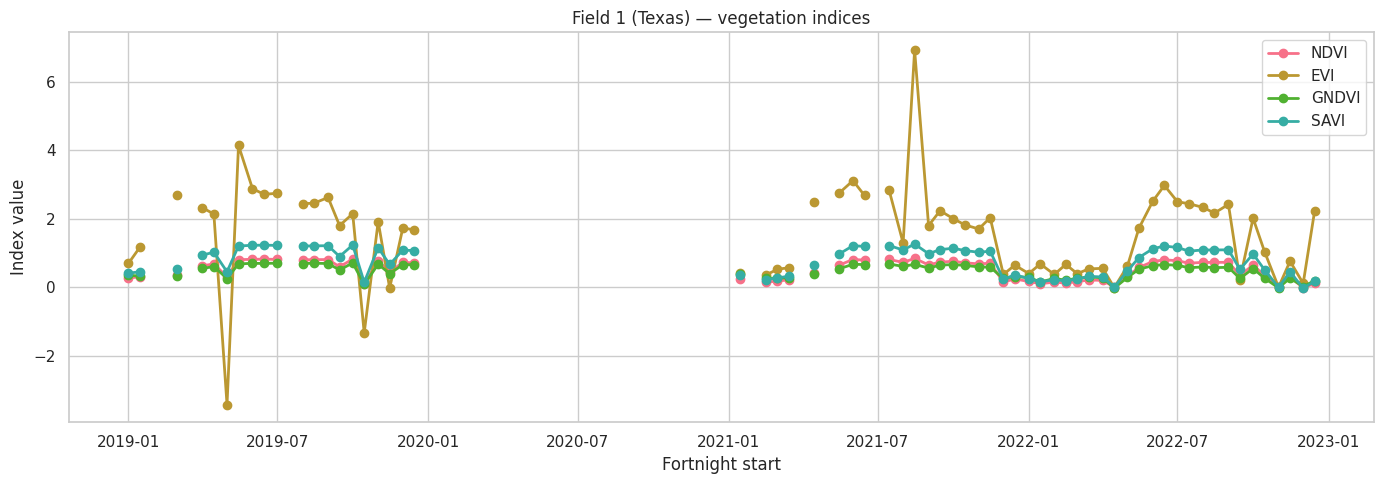

In [10]:
# Single-field time series (check one field's fortnight trajectory)
if SAMPLE_FIELD_ID in df['field_id'].values:
    field_df = df[df['field_id'] == SAMPLE_FIELD_ID]
    state_name = field_df['state'].iloc[0]
    fig, ax = plt.subplots(figsize=(14, 5))
    for feat in VEG_FEATURES:
        ax.plot(field_df['fortnight_start'], field_df[feat], marker='o', label=feat, linewidth=2)
    ax.set_title(f'Field {SAMPLE_FIELD_ID} ({state_name}) — vegetation indices')
    ax.set_xlabel('Fortnight start')
    ax.set_ylabel('Index value')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'SAMPLE_FIELD_ID={SAMPLE_FIELD_ID} not in dataset. Pick from:', df['field_id'].unique()[:10])


## 3. Distributions (Sugarcane EDA pattern)


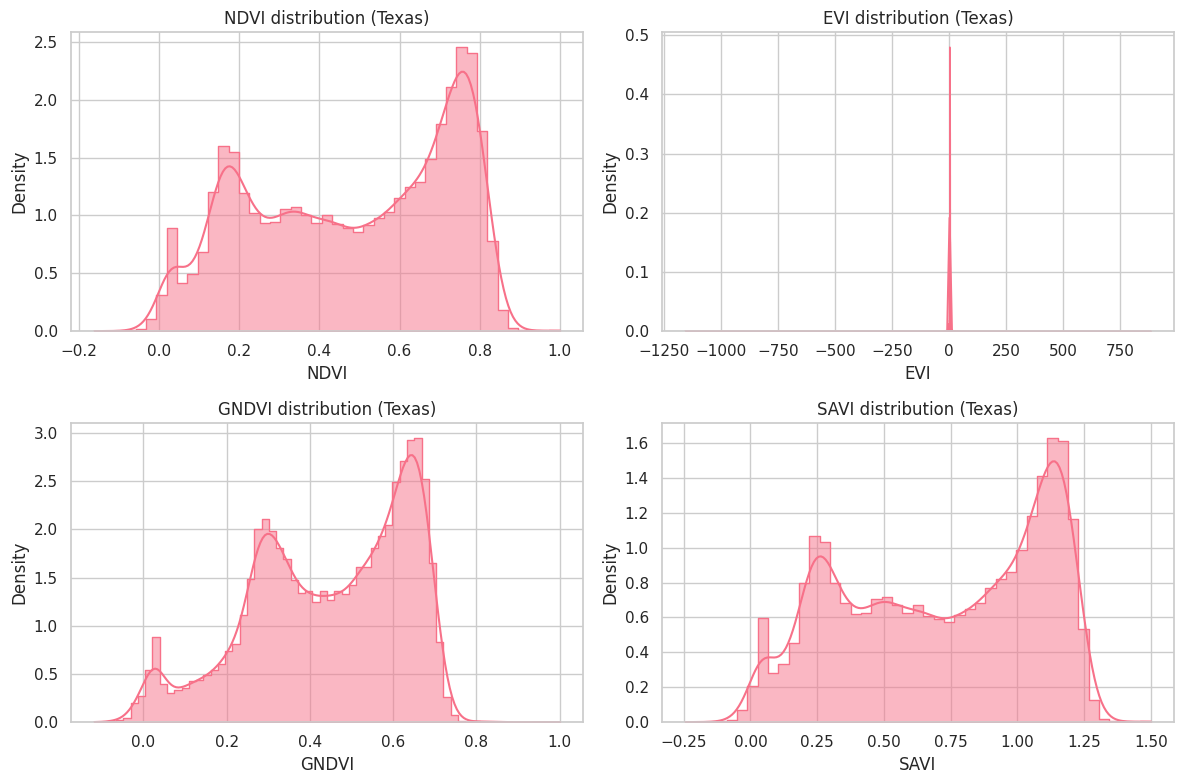

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, feat in zip(axes, VEG_FEATURES):
    if df['state'].nunique() > 1:
        sns.histplot(data=df, x=feat, hue='state', kde=True, ax=ax, element='step', stat='density', common_norm=False)
        ax.set_title(f'{feat} distribution by state')
    else:
        sns.histplot(data=df, x=feat, kde=True, ax=ax, element='step', stat='density')
        ax.set_title(f'{feat} distribution (Texas)')
plt.tight_layout()
plt.show()

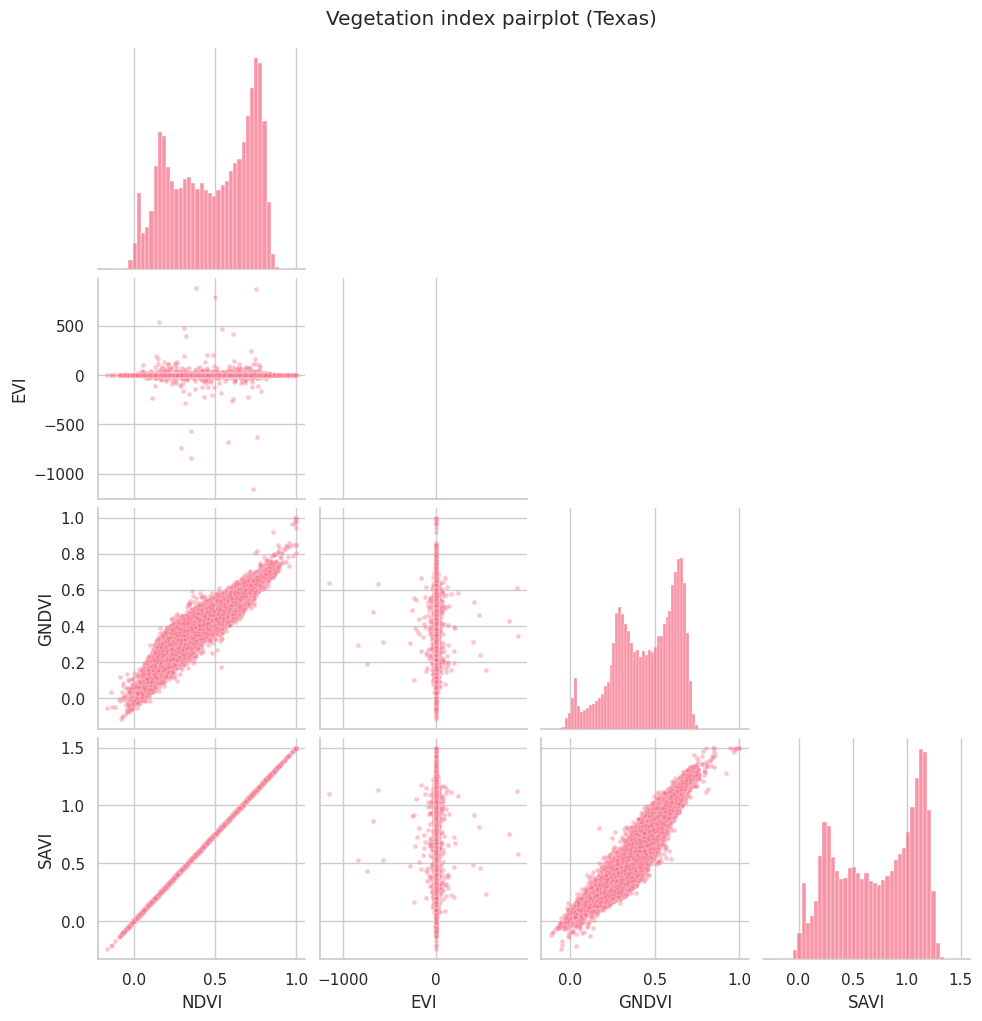

In [12]:
# Pairwise relationships — hue by state when multiple states exist
pair_cols = VEG_FEATURES + (['state'] if df['state'].nunique() > 1 else [])
plot_df = df[pair_cols].dropna()
if df['state'].nunique() > 1:
    sns.pairplot(plot_df, hue='state', corner=True, plot_kws={'alpha': 0.4, 's': 12})
    plt.suptitle('Vegetation index pairplot by state', y=1.02)
else:
    sns.pairplot(plot_df.drop(columns=['state'], errors='ignore'), corner=True, plot_kws={'alpha': 0.4, 's': 12})
    plt.suptitle('Vegetation index pairplot (Texas)', y=1.02)
plt.show()


## 4. Correlation heatmap


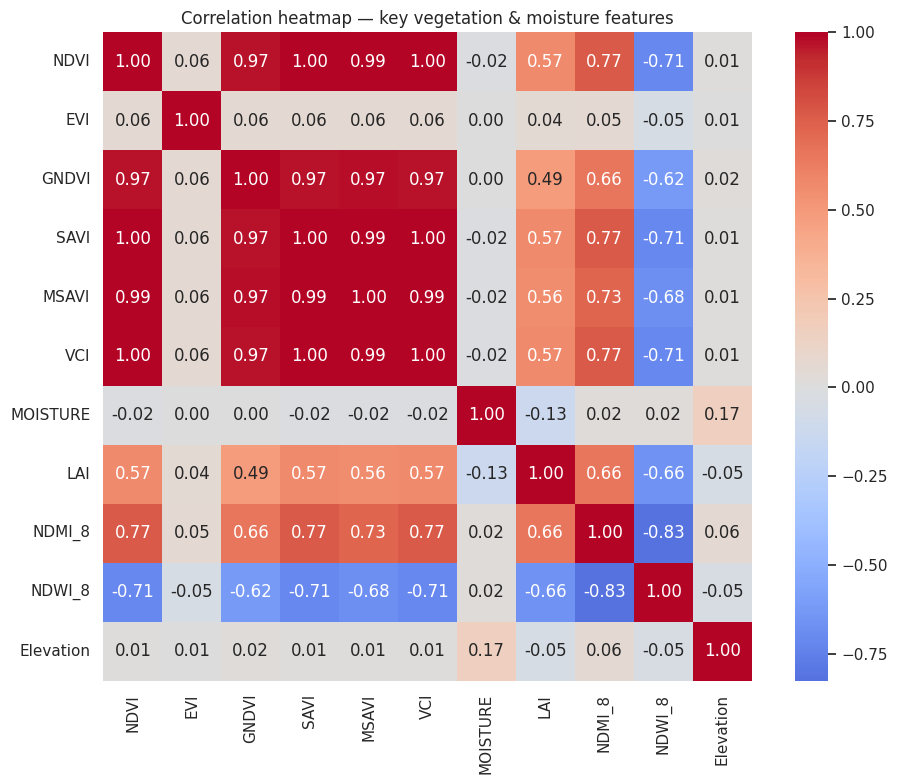

In [13]:
corr_cols = [c for c in CORR_FEATURES if c in df.columns]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap — key vegetation & moisture features')
plt.tight_layout()
plt.show()


## 5. Data quality — Sentinel-2 coverage


/tmp/ipykernel_1141/2693439101.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_pct = df.groupby('state').apply(lambda x: (x['s2_scene_count'] == 0).mean() * 100)


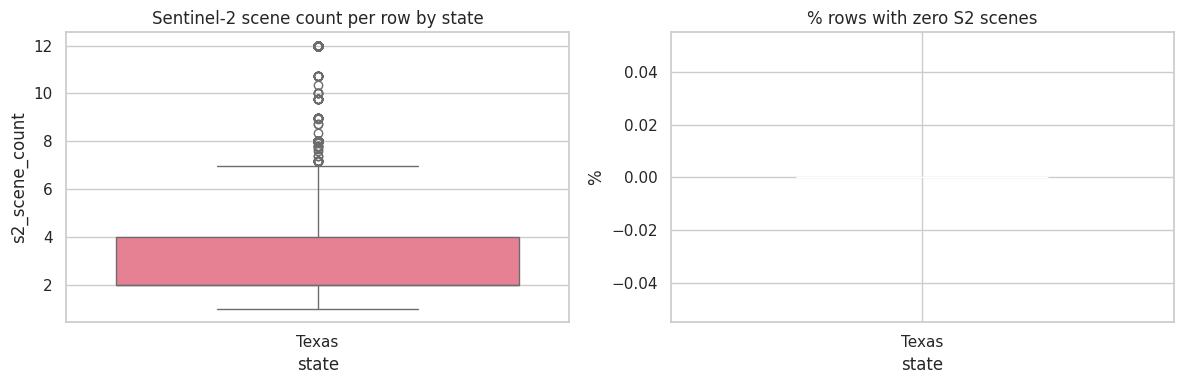

In [14]:
if 's2_scene_count' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=df, x='state', y='s2_scene_count', ax=axes[0])
    axes[0].set_title('Sentinel-2 scene count per row by state')

    zero_pct = df.groupby('state').apply(lambda x: (x['s2_scene_count'] == 0).mean() * 100)
    zero_pct.plot(kind='bar', ax=axes[1], color=sns.color_palette('husl', len(zero_pct)))
    axes[1].set_title('% rows with zero S2 scenes')
    axes[1].set_ylabel('%')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print('s2_scene_count column not found — re-run Phase 1 with latest notebook')

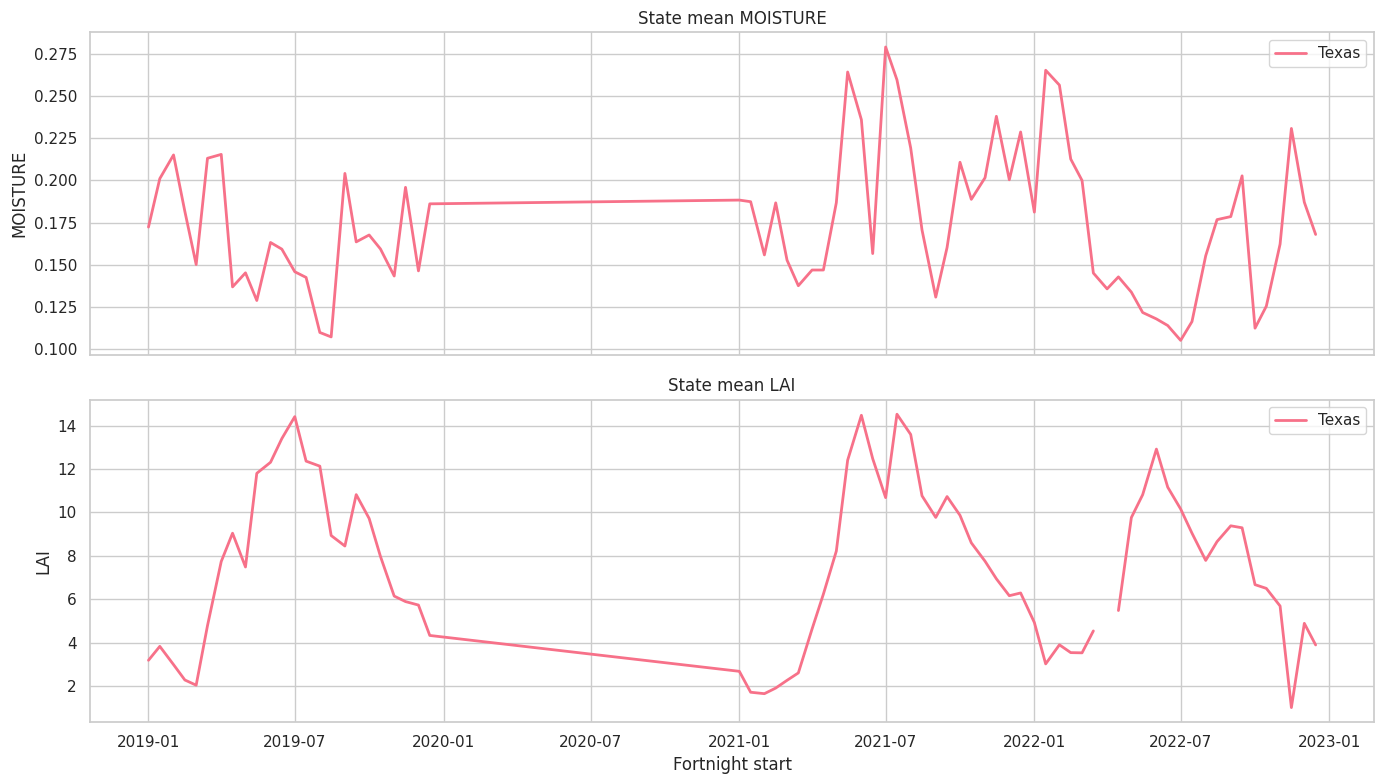

In [15]:
# Optional: MOISTURE & LAI state means over time
moist_cols = [c for c in EXTRA_FEATURES if c in df.columns]
if moist_cols:
    fig, axes = plt.subplots(len(moist_cols), 1, figsize=(14, 4 * len(moist_cols)), sharex=True)
    if len(moist_cols) == 1:
        axes = [axes]
    for ax, feat in zip(axes, moist_cols):
        state_mean = df.groupby(['state', 'fortnight_start'])[feat].mean().reset_index()
        for state in sorted(df['state'].dropna().unique()):
            sub = state_mean[state_mean['state'] == state]
            ax.plot(sub['fortnight_start'], sub[feat], label=state, linewidth=2)
        ax.set_ylabel(feat)
        ax.legend()
        ax.set_title(f'State mean {feat}')
    axes[-1].set_xlabel('Fortnight start')
    plt.tight_layout()
    plt.show()